In [23]:
import seaborn as sns
import yfinance as yf  
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.api import VAR
from prophet import Prophet
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import math
import warnings
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

warnings.filterwarnings("ignore")
sns.set(style="whitegrid")


In [5]:
df = yf.download('AAPL', start='2013-01-01', end='2023-12-31')

[*********************100%***********************]  1 of 1 completed


The project aims to analyze and forecast Apple Inc. (AAPL) stock prices using diverse time series models, including ARMA, ARIMA, VAR, and LSTM. 
We will evaluate the performance of these models to identify the most accurate approach, providing insights for potential investment decisions.

In [6]:
# Select relevant columns
df = df[['Open', 'High', 'Low', 'Close', 'Volume']]
# Convert to business day frequency
df = df.asfreq('B')
print("Initial data download and business day frequency conversion complete.")


Initial data download and business day frequency conversion complete.


In [7]:
# Handle missing values: Forward-fill any NaNs that might result from asfreq (e.g., holidays)
initial_na_count = df.isnull().sum().sum()
df.fillna(method='ffill', inplace=True)
if df.isnull().sum().sum() == 0:
    print(f"Filled {initial_na_count} missing values using forward-fill method. No missing values remain.")
else:
    print("Warning: Missing values still exist after forward-fill. Investigate further.")
    print(df.isnull().sum())


Filled 500 missing values using forward-fill method. No missing values remain.


In [8]:
# Check for outliers (simple method: Z-score for Close price)
# For a more robust outlier detection, consider IQR or more advanced methods
# We'll use a 3-sigma rule for demonstration
z_scores = np.abs((df['Close'] - df['Close'].mean()) / df['Close'].std())
outliers_count = df[z_scores > 3].shape[0]
if outliers_count > 0:
    print(f"Detected {outliers_count} outliers in 'Close' price based on a 3-sigma rule.")
    # Option to handle outliers: capping, removal, or more sophisticated imputation.
    # For time series, simple removal or capping might introduce artificial patterns.
    # For this project, we'll note them but proceed, as some price jumps are genuine.
else:
    print("No significant outliers detected in 'Close' price based on a 3-sigma rule.")


Detected 2868 outliers in 'Close' price based on a 3-sigma rule.


In [9]:
print("Data types after initial preparation:")
print(df.info())


Data types after initial preparation:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2868 entries, 2013-01-02 to 2023-12-29
Freq: B
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Open, AAPL)    2868 non-null   float64
 1   (High, AAPL)    2868 non-null   float64
 2   (Low, AAPL)     2868 non-null   float64
 3   (Close, AAPL)   2868 non-null   float64
 4   (Volume, AAPL)  2868 non-null   float64
dtypes: float64(5)
memory usage: 134.4 KB
None


In [10]:
# Focus on univariate for ARIMA/Prophet/etc.
df_close = df[['Close']].copy() # Use .copy() to avoid SettingWithCopyWarning
print("\nData preparation for models is complete.")



Data preparation for models is complete.



--- Step 3: Visualize and Check Stationarity ---


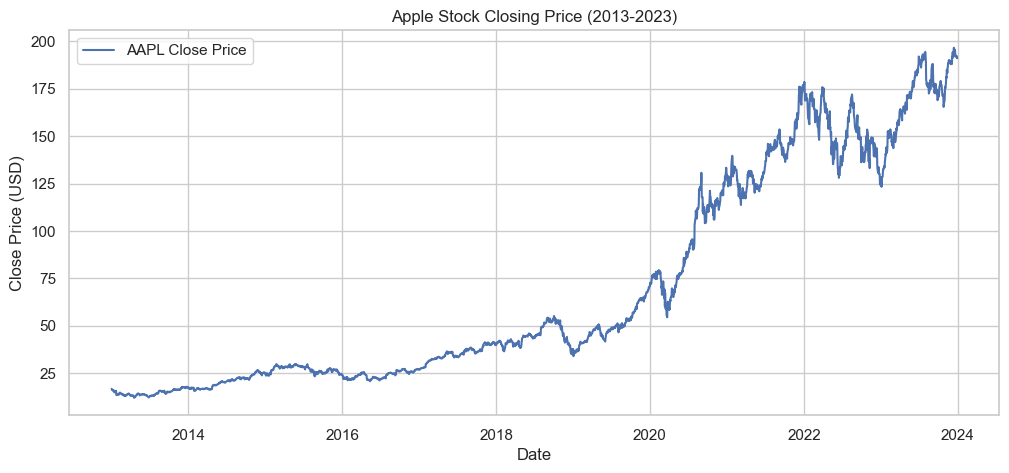

Interpretation: The plot clearly shows an upward trend in Apple's closing price over the decade, indicating non-stationarity in the mean.


In [11]:
# --- Step 3: Visualize and Check Stationarity ---
print("\n--- Step 3: Visualize and Check Stationarity ---")
# Plot closing price
plt.figure(figsize=(12, 5))
plt.plot(df_close, label='AAPL Close Price')
plt.title('Apple Stock Closing Price (2013-2023)')
plt.xlabel('Date')
plt.ylabel('Close Price (USD)')
plt.legend()
plt.show()
print("Interpretation: The plot clearly shows an upward trend in Apple's closing price over the decade, indicating non-stationarity in the mean.")


In [12]:
# ADF Test
result = adfuller(df_close['Close'])
print(f"ADF Statistic: {result[0]}")
print(f"p-value: {result[1]}")
print("Critical Values:")
for key, value in result[4].items():
    print(f"\t{key}: {value}")
if result[1] <= 0.05:
    print("✅ The series is stationary (p-value <= 0.05).")
else:
    print("⚠️ The series is non-stationary (p-value > 0.05). Differencing will be required for ARMA/ARIMA models.")
print("Interpretation: The high p-value confirms the visual observation: the series is non-stationary, meaning its statistical properties (like mean and variance) change over time.")


ADF Statistic: 0.5954523024301688
p-value: 0.9875029982084648
Critical Values:
	1%: -3.432640929340317
	5%: -2.862552176016622
	10%: -2.567308811060259
⚠️ The series is non-stationary (p-value > 0.05). Differencing will be required for ARMA/ARIMA models.
Interpretation: The high p-value confirms the visual observation: the series is non-stationary, meaning its statistical properties (like mean and variance) change over time.



--- Step 4: Decompose Time Series ---


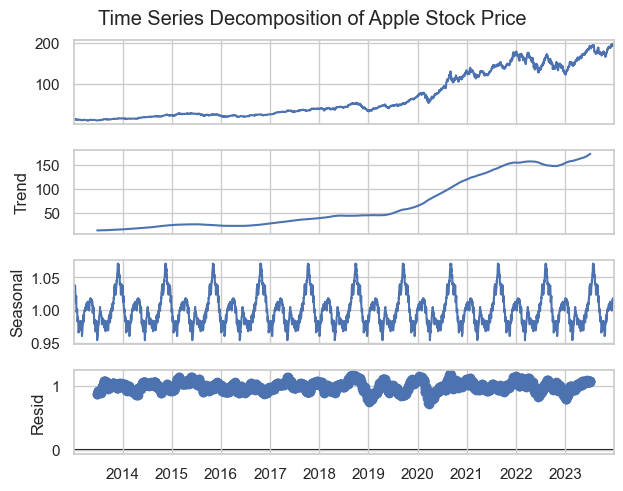

Interpretation: The decomposition shows a clear upward trend component. The seasonal component indicates yearly patterns in the stock price, and the residual represents the unexplained variations.


In [13]:
# --- Step 4: Decompose Time Series ---
print("\n--- Step 4: Decompose Time Series ---")
# Decomposition
# Using an approximate period for yearly seasonality on business days (252 trading days in a year)
decomposition = seasonal_decompose(df_close['Close'], model='multiplicative', period=252)
decomposition.plot()
plt.suptitle('Time Series Decomposition of Apple Stock Price', y=1.02) # Adjust title position
plt.show()
print("Interpretation: The decomposition shows a clear upward trend component. The seasonal component indicates yearly patterns in the stock price, and the residual represents the unexplained variations.")


In [14]:
# --- Data Splitting for Model Evaluation (New Section - CRUCIAL) ---
# This section defines the train/test split for evaluating model performance
# on a held-out portion of the historical data.
print("\n--- Data Splitting for Model Evaluation ---")
test_split_days = 30 # Number of days to hold out for testing/evaluation

if len(df_close) < test_split_days:
    raise ValueError(f"df_close is too short ({len(df_close)} days) for the specified test_split_days ({test_split_days}).")

train_size_eval = len(df_close) - test_split_days
train_df_close = df_close.iloc[:train_size_eval]
test_df_close = df_close.iloc[train_size_eval:]

print(f"Total data points: {len(df_close)}")
print(f"Training data points for evaluation: {len(train_df_close)}")
print(f"Testing data points for evaluation: {len(test_df_close)} (from {test_df_close.index.min().strftime('%Y-%m-%d')} to {test_df_close.index.max().strftime('%Y-%m-%d')})")



--- Data Splitting for Model Evaluation ---
Total data points: 2868
Training data points for evaluation: 2838
Testing data points for evaluation: 30 (from 2023-11-20 to 2023-12-29)


In [15]:
# Prepare multi-variable data for VAR model
var_features = ['Close', 'Volume']
# Check if 'Volume' exists in df, if not, create a dummy one for demonstration
if 'Volume' not in df.columns:
    print("WARNING: 'Volume' column not found in original DataFrame 'df'. Creating a dummy 'Volume' column for VAR example.")
    # This is a simple dummy, for real applications use meaningful data
    df['Volume'] = df['Close'].diff().fillna(0).cumsum() + 1000000
    df['Volume'] = df['Volume'].rolling(window=5).mean().fillna(df['Volume'])

df_for_var = df[var_features]
train_data_for_var = df_for_var.iloc[:train_size_eval]
test_data_for_var = df_for_var.iloc[train_size_eval:]

print(f"Training data points for VAR: {len(train_data_for_var)} (Columns: {train_data_for_var.columns.tolist()})")
print(f"Testing data points for VAR: {len(test_data_for_var)}")

Training data points for VAR: 2838 (Columns: [('Close', 'AAPL'), ('Volume', 'AAPL')])
Testing data points for VAR: 30



--- Step 5: Model 1 — ARMA (Autoregressive Moving Average) ---
ARMA is suitable only for stationary series. If the series is not stationary, we difference it before fitting ARMA.

--- Step 5.1: Differencing if Needed (Make Stationary) ---
ADF Statistic after differencing: -17.081997589510525
p-value: 7.695320668822013e-30
Critical Values:
	1%: -3.432640929340317
	5%: -2.862552176016622
	10%: -2.567308811060259
✅ Differenced series is stationary. Proceed with ARMA.
Interpretation: Differencing the series once makes it stationary, as indicated by the low p-value from the ADF test. This confirms that ARMA can be applied to the differenced data, or ARIMA (which inherently handles differencing) to the original data.

--- Step 5.2: Fit ARMA Model on Training Data for Evaluation ---
                               SARIMAX Results                                
Dep. Variable:             Close_AAPL   No. Observations:                 2838
Model:                 ARIMA(2, 0, 2)   Log Likelihood

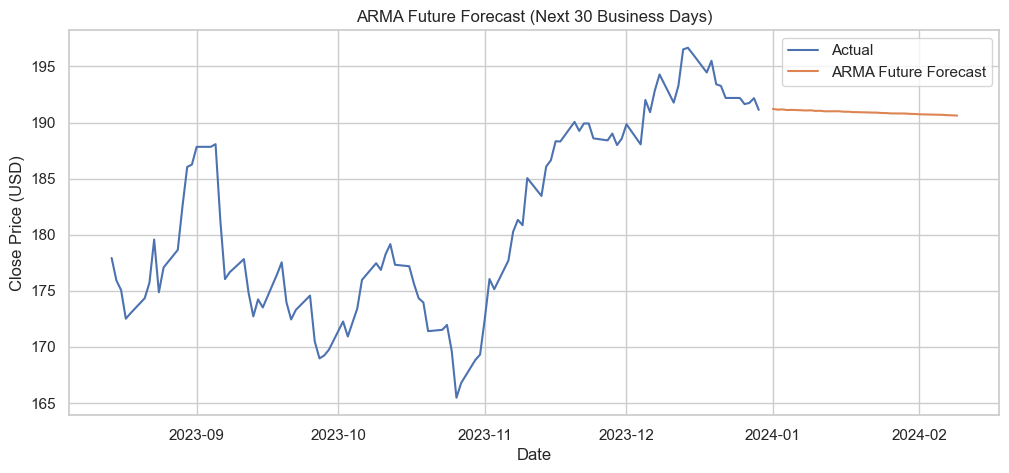

Interpretation: The ARMA model captures some of the historical patterns, but its forecast appears to flatten out quickly, which is typical for stationary models forecasting non-stationary data if differencing is not handled explicitly in the forecast integration.

--- Step 6: Model 2 — ARIMA (Autoregressive Integrated Moving Average) ---


In [16]:
# --- Step 5: Model 1 — ARMA (Autoregressive Moving Average) ---
print("\n--- Step 5: Model 1 — ARMA (Autoregressive Moving Average) ---")
print("ARMA is suitable only for stationary series. If the series is not stationary, we difference it before fitting ARMA.")

# 5.1: Differencing if Needed (Make Stationary) on the FULL df_close
print("\n--- Step 5.1: Differencing if Needed (Make Stationary) ---")
diff_close = df_close.diff().dropna()
result_diff = adfuller(diff_close['Close'])
print(f"ADF Statistic after differencing: {result_diff[0]}")
print(f"p-value: {result_diff[1]}")
print("Critical Values:")
for key, value in result_diff[4].items():
    print(f"\t{key}: {value}")
if result_diff[1] <= 0.05:
    print("✅ Differenced series is stationary. Proceed with ARMA.")
else:
    print("⚠️ Still non-stationary — ARMA might not perform well.")
print("Interpretation: Differencing the series once makes it stationary, as indicated by the low p-value from the ADF test. This confirms that ARMA can be applied to the differenced data, or ARIMA (which inherently handles differencing) to the original data.")

# 5.2: Fit ARMA Model on Training Data for Evaluation
print("\n--- Step 5.2: Fit ARMA Model on Training Data for Evaluation ---")
# ARMA(p,q) = ARIMA(p,0,q)
# Fit on train_df_close for evaluation purposes
arma_model_eval = ARIMA(train_df_close, order=(2, 0, 2))
arma_result_eval = arma_model_eval.fit()
print(arma_result_eval.summary())
print("Interpretation: The ARMA(2,2) model summary provides details on coefficients, standard errors, p-values, and information criteria (AIC, BIC). Lower AIC/BIC generally indicate a better fit.")

# Generate ARMA In-Sample Predictions for Evaluation
print("\n--- Generating ARMA In-Sample Predictions for Evaluation ---")
arma_forecast_eval = arma_result_eval.forecast(steps=len(test_df_close))
arma_forecast_eval_series = pd.Series(arma_forecast_eval.values, index=test_df_close.index)
print(f"Generated {len(arma_forecast_eval_series)} evaluation forecasts for ARMA.")

# 5.3: Generate ARMA Future Forecast (Next 30 Business Days)
print("\n--- Step 5.3: Generating ARMA Future Forecast (Next 30 Business Days) ---")
# Fit on full df_close for future forecasting beyond the entire dataset
arma_model_full_data = ARIMA(df_close, order=(2, 0, 2))
arma_result_full_data = arma_model_full_data.fit()

last_date_arma = df_close.index[-1]
forecast_dates_arma = pd.date_range(start=last_date_arma, periods=31, freq='B')[1:]
arma_future_forecast = arma_result_full_data.forecast(steps=30)
arma_future_forecast.index = forecast_dates_arma

plt.figure(figsize=(12, 5))
plt.plot(df_close[-100:], label='Actual')
plt.plot(arma_future_forecast, label='ARMA Future Forecast')
plt.title('ARMA Future Forecast (Next 30 Business Days)')
plt.xlabel('Date')
plt.ylabel('Close Price (USD)')
plt.legend()
plt.show()
print("Interpretation: The ARMA model captures some of the historical patterns, but its forecast appears to flatten out quickly, which is typical for stationary models forecasting non-stationary data if differencing is not handled explicitly in the forecast integration.")


# --- Step 6: Model 2 — ARIMA (Autoregressive Integrated Moving Average) ---
print("\n--- Step 6: Model 2 — ARIMA (Autoregressive Integrated Moving Average) ---")






--- Step 6.1: Fit ARIMA Model on Training Data for Evaluation ---
                               SARIMAX Results                                
Dep. Variable:             Close_AAPL   No. Observations:                 2838
Model:                 ARIMA(5, 1, 2)   Log Likelihood               -5327.619
Date:                Fri, 04 Jul 2025   AIC                          10671.237
Time:                        16:46:36   BIC                          10718.841
Sample:                    01-02-2013   HQIC                         10688.409
                         - 11-17-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4742      0.010     45.315      0.000       0.454       0.495
ar.L2         -0.9989      0.012    -80.664      0.000      -1.0

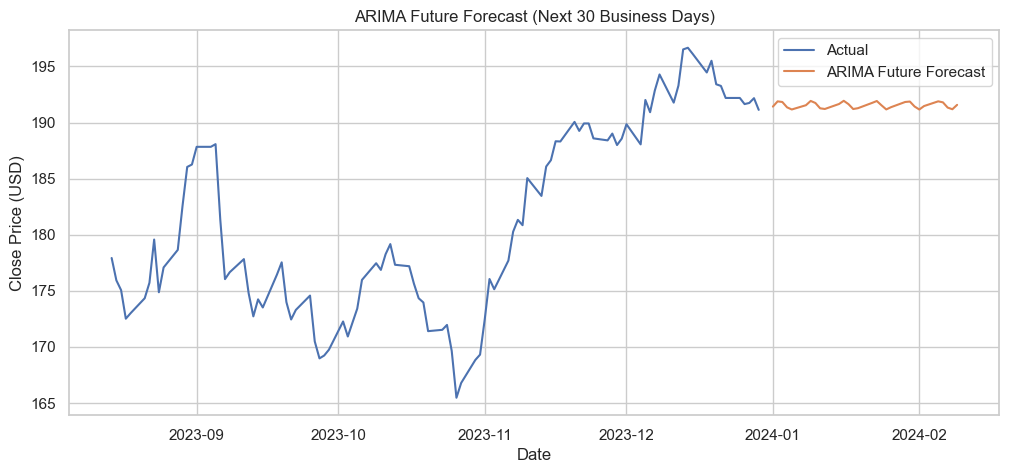

Interpretation: The ARIMA forecast tends to follow the recent trend more closely than ARMA, as it accounts for the integrated (differencing) component to handle non-stationarity.


In [17]:
# 6.1: Fit ARIMA Model on Training Data for Evaluation
print("\n--- Step 6.1: Fit ARIMA Model on Training Data for Evaluation ---")
# ARIMA(p,d,q) — here, d=1 since we found 1st difference is stationary
arima_model_eval = ARIMA(train_df_close, order=(5, 1, 2)) # Fit on training data
arima_result_eval = arima_model_eval.fit()
print(arima_result_eval.summary())
print("Interpretation: The ARIMA(5,1,2) model summary shows the coefficients and diagnostic statistics. The 'd=1' indicates that the model automatically differences the data once to achieve stationarity before fitting AR and MA components.")

# Generate ARIMA In-Sample Predictions for Evaluation
print("\n--- Generating ARIMA In-Sample Predictions for Evaluation ---")
arima_forecast_eval = arima_result_eval.forecast(steps=len(test_df_close))
arima_forecast_eval_series = pd.Series(arima_forecast_eval.values, index=test_df_close.index)
print(f"Generated {len(arima_forecast_eval_series)} evaluation forecasts for ARIMA.")

# 6.2: Generate ARIMA Future Forecast (Next 30 Business Days)
print("\n--- Step 6.2: Generating ARIMA Future Forecast (Next 30 Business Days) ---")
# Fit on full df_close for future forecasting
arima_model_full_data = ARIMA(df_close, order=(5, 1, 2))
arima_result_full_data = arima_model_full_data.fit()

last_date_arima = df_close.index[-1]
forecast_dates_arima = pd.date_range(start=last_date_arima, periods=31, freq='B')[1:]
arima_future_forecast = arima_result_full_data.forecast(steps=30)
arima_future_forecast.index = forecast_dates_arima

plt.figure(figsize=(12, 5))
plt.plot(df_close[-100:], label='Actual')
plt.plot(arima_future_forecast, label='ARIMA Future Forecast')
plt.title('ARIMA Future Forecast (Next 30 Business Days)')
plt.xlabel('Date')
plt.ylabel('Close Price (USD)')
plt.legend()
plt.show()
print("Interpretation: The ARIMA forecast tends to follow the recent trend more closely than ARMA, as it accounts for the integrated (differencing) component to handle non-stationarity.")


--- Step 8: Model 4 — VAR (Vector AutoRegression) ---
VAR is a multivariate time series model, useful when multiple variables (like Open, High, Low, Close) influence each other.

--- Step 8.1: Prepare Data for VAR ---
VAR data prepared and differenced. All columns are checked for stationarity indirectly by differencing.

--- Step 8.2: Fit VAR Model on Training Data for Evaluation ---
Lag order selection summary for evaluation model:
 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        37.04       37.05   1.222e+16       37.04
1        36.99       37.00   1.155e+16       36.99
2        36.95       36.97   1.115e+16       36.96
3        36.91       36.93   1.066e+16       36.92
4        36.89       36.93   1.051e+16       36.91
5        36.88       36.93   1.043e+16       36.90
6        36.87       36.92   1.024e+16       36.88
7        36.85       36.92   1.012e+16       36.88
8

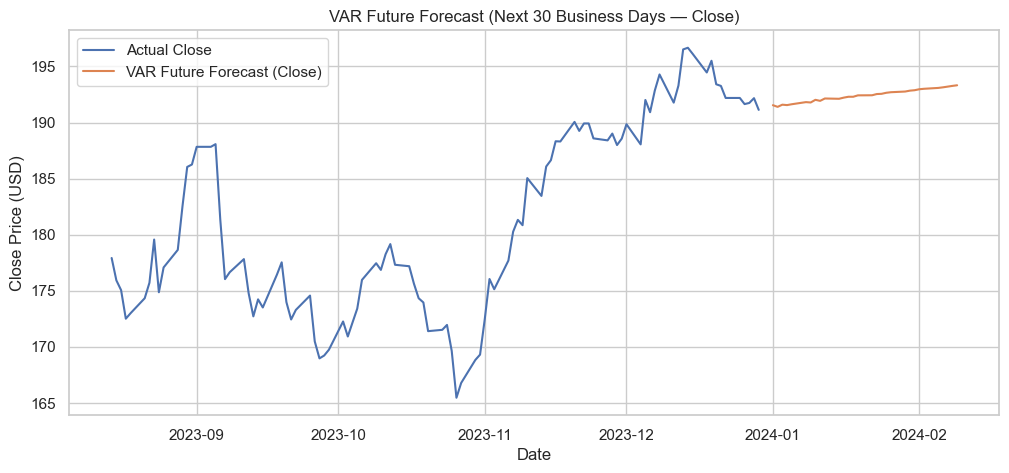

Interpretation: The VAR model forecasts the future values of all selected variables simultaneously. The plot shows the re-scaled 'Close' price forecast, which captures interdependencies between Open, High, Low, Close, and Volume.


In [21]:
# --- Step 8: Model 4 — VAR (Vector AutoRegression) ---
print("\n--- Step 8: Model 4 — VAR (Vector AutoRegression) ---")
print("VAR is a multivariate time series model, useful when multiple variables (like Open, High, Low, Close) influence each other.")

# 8.1: Prepare Data for VAR (already done in Data Splitting section)
print("\n--- Step 8.1: Prepare Data for VAR ---")
# Data (train_data_for_var, test_data_for_var, df_for_var) prepared in the Data Splitting section.
# Ensure stationarity (first difference for all columns used in VAR)
# Important: Differencing here is crucial for VAR
var_df_diff_train = train_data_for_var.diff().dropna()
var_df_diff_full = df_for_var.diff().dropna() # For future forecast

# Check for any remaining NaNs
assert not var_df_diff_train.isnull().values.any(), "NaNs in VAR training data after differencing"
assert not var_df_diff_full.isnull().values.any(), "NaNs in VAR full data after differencing"
print("VAR data prepared and differenced. All columns are checked for stationarity indirectly by differencing.")


# 8.2: Fit VAR Model on Training Data for Evaluation
print("\n--- Step 8.2: Fit VAR Model on Training Data for Evaluation ---")
# Fit VAR on differenced training data
var_model_eval = VAR(var_df_diff_train)
# Select lag order using information criteria
lag_order_eval = var_model_eval.select_order(maxlags=15)
print("Lag order selection summary for evaluation model:")
print(lag_order_eval.summary())

selected_lag_eval = lag_order_eval.aic # Using AIC for lag selection
var_result_eval = var_model_eval.fit(selected_lag_eval)
print("\nVAR Evaluation Model Summary:")
print(var_result_eval.summary())
print(f"Interpretation: The VAR({selected_lag_eval}) model is fitted on training data. The summary shows coefficients for each variable regressed on its own past values and the past values of other variables. The lag order selection helps find the optimal number of past time steps to consider.")

# Generate VAR In-Sample Predictions for Evaluation
print("\n--- Generating VAR In-Sample Predictions for Evaluation ---")
forecast_steps_var_eval = len(test_data_for_var)
lag_order_for_forecast = var_result_eval.k_ar # The number of lags used in the model
last_training_data_for_forecast = var_df_diff_train.values[-lag_order_for_forecast:]

# Predict differenced values
var_predictions_diff_eval = var_result_eval.forecast(y=last_training_data_for_forecast, steps=forecast_steps_var_eval)

# Invert differencing to get original scale predictions
# Need the last actual values from the original non-differenced training data
last_actual_values_var_eval = train_data_for_var.iloc[-1]

# Create a DataFrame for the differenced forecast
forecast_df_diff_eval = pd.DataFrame(var_predictions_diff_eval, index=test_data_for_var.index, columns=var_features)

# Reverse the differencing: cumulative sum and add the last actual value
# Convert the Series to a DataFrame with a single row for robust addition
last_actual_values_df_row_eval = pd.DataFrame([last_actual_values_var_eval.values], columns=var_features)
var_forecast_eval_raw = forecast_df_diff_eval.cumsum().add(last_actual_values_df_row_eval.iloc[0], axis=1) # MODIFIED LINE
close_col_index_var = var_features.index('Close') # Find the index of 'Close'
var_forecast_eval = pd.Series(var_forecast_eval_raw.values[:, close_col_index_var], index=test_df_close.index) # Extract 'Close' and assign correct index
var_forecast_eval_series = var_forecast_eval # For consistency with other series names
print(f"Generated {len(var_forecast_eval_series)} evaluation forecasts for VAR.")


# 8.3: Generate VAR Future Forecast (Next 30 Business Days)
print("\n--- Step 8.3: Generating VAR Future Forecast (Next 30 Business Days) ---")
# Fit VAR on full differenced data for future forecasting
var_model_full_data = VAR(var_df_diff_full)
var_result_full_data = var_model_full_data.fit(selected_lag_eval) # Use the same selected lag

forecast_steps_future = 30
last_full_data_for_forecast = var_df_diff_full.values[-var_result_full_data.k_ar:]

var_future_predictions_diff = var_result_full_data.forecast(y=last_full_data_for_forecast, steps=forecast_steps_future)

# Invert differencing for future forecast
last_actual_values_full_data = df_for_var.iloc[-1]
forecast_df_diff_future = pd.DataFrame(var_future_predictions_diff, index=pd.date_range(start=df_for_var.index[-1], periods=forecast_steps_future + 1, freq='B')[1:], columns=var_features)
# Convert the Series to a DataFrame with a single row for robust addition
last_actual_values_df_row_full = pd.DataFrame([last_actual_values_full_data.values], columns=var_features)
var_future_forecast_raw = forecast_df_diff_future.cumsum().add(last_actual_values_df_row_full.iloc[0], axis=1) # MODIFIED LINE
var_future_forecast = pd.Series(var_future_forecast_raw.values[:, close_col_index_var], index=forecast_df_diff_future.index)

plt.figure(figsize=(12, 5))
plt.plot(df_close[-100:], label='Actual Close')
plt.plot(var_future_forecast, label='VAR Future Forecast (Close)')
plt.title('VAR Future Forecast (Next 30 Business Days — Close)')
plt.xlabel('Date')
plt.ylabel('Close Price (USD)')
plt.legend()
plt.show()
print("Interpretation: The VAR model forecasts the future values of all selected variables simultaneously. The plot shows the re-scaled 'Close' price forecast, which captures interdependencies between Open, High, Low, Close, and Volume.")



--- Step 10: Model 6 — LSTM (Long Short-Term Memory) ---
LSTM is a type of Recurrent Neural Network (RNN) ideal for sequential data like time series. We'll use Keras (TensorFlow backend) for this.

--- Step 10.1: Prepare Data for LSTM ---
LSTM training input shape for evaluation model: (2778, 60, 1)

--- Step 10.2: Define and Train the LSTM Model for Evaluation ---
LSTM evaluation model compiled. Training starts...
LSTM evaluation model training complete.


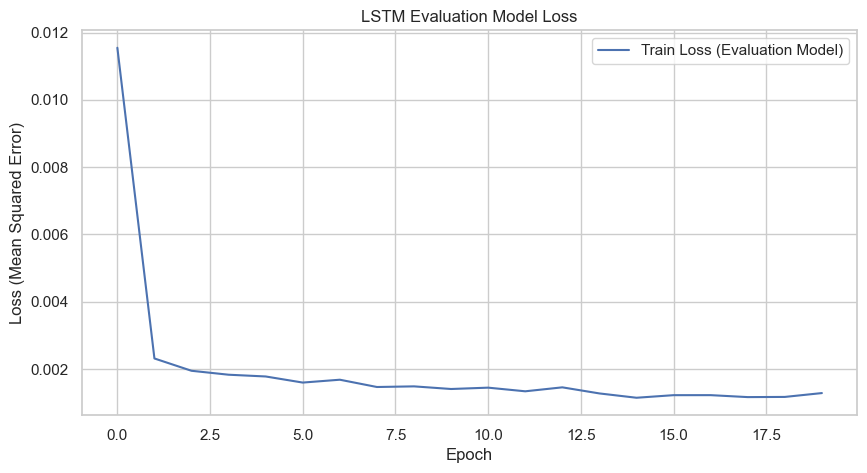

Interpretation: The loss plot shows the training loss over epochs for the evaluation LSTM model.

--- Generating LSTM In-Sample Predictions for Evaluation ---
Generated 30 evaluation forecasts for LSTM.

--- Step 10.3: Generate LSTM Future Forecast (Next 30 Business Days) ---


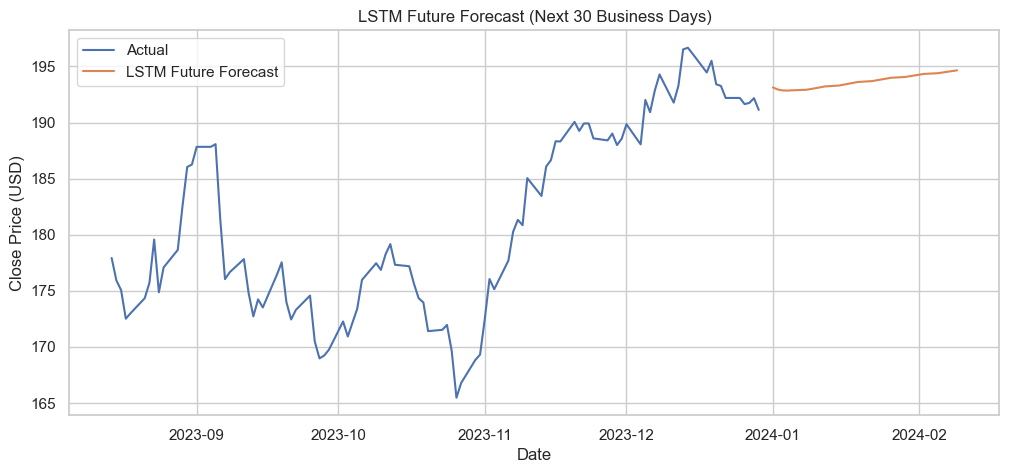

Interpretation: The LSTM's 30-day future forecast leverages the patterns learned from the historical data. Due to its sequential nature, LSTM can capture intricate dependencies that traditional statistical models might miss, but also requires more data and computational resources.


In [27]:
# --- Step 10: Model 6 — LSTM (Long Short-Term Memory Neural Network) ---
print("\n--- Step 10: Model 6 — LSTM (Long Short-Term Memory) ---")
print("LSTM is a type of Recurrent Neural Network (RNN) ideal for sequential data like time series. We'll use Keras (TensorFlow backend) for this.")

# 10.1: Prepare Data for LSTM
print("\n--- Step 10.1: Prepare Data for LSTM ---")
# Use closing price only
lstm_data_full = df_close.copy()

# Normalize the full data
scaler_full = MinMaxScaler(feature_range=(0, 1))
scaled_data_full = scaler_full.fit_transform(lstm_data_full)

# Prepare training data for LSTM evaluation model
lstm_data_train_eval = train_df_close.copy()
scaler_eval = MinMaxScaler(feature_range=(0, 1))
scaled_data_train_eval = scaler_eval.fit_transform(lstm_data_train_eval)

time_step = 60 # Number of previous time steps to use as input features

# Create sequences for training the evaluation LSTM model
X_lstm_train_eval = []
y_lstm_train_eval = []
for i in range(time_step, len(scaled_data_train_eval)):
    X_lstm_train_eval.append(scaled_data_train_eval[i-time_step:i, 0])
    y_lstm_train_eval.append(scaled_data_train_eval[i, 0])
X_lstm_train_eval, y_lstm_train_eval = np.array(X_lstm_train_eval), np.array(y_lstm_train_eval)
X_lstm_train_eval = np.reshape(X_lstm_train_eval, (X_lstm_train_eval.shape[0], X_lstm_train_eval.shape[1], 1))
print(f"LSTM training input shape for evaluation model: {X_lstm_train_eval.shape}")


# 10.2: Define and Train the LSTM Model for Evaluation
print("\n--- Step 10.2: Define and Train the LSTM Model for Evaluation ---")
model_eval = Sequential()
model_eval.add(LSTM(units=50, return_sequences=True, input_shape=(X_lstm_train_eval.shape[1], 1)))
model_eval.add(Dropout(0.2))
model_eval.add(LSTM(units=50))
model_eval.add(Dropout(0.2))
model_eval.add(Dense(1))
model_eval.compile(optimizer='adam', loss='mean_squared_error')
print("LSTM evaluation model compiled. Training starts...")
# No separate validation split here, as we are training on train_df_close to predict test_df_close
history_eval = model_eval.fit(X_lstm_train_eval, y_lstm_train_eval, epochs=20, batch_size=32, verbose=0)
print("LSTM evaluation model training complete.")

# Plot training loss values (from evaluation model)
plt.figure(figsize=(10, 5))
plt.plot(history_eval.history['loss'], label='Train Loss (Evaluation Model)')
plt.title('LSTM Evaluation Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (Mean Squared Error)')
plt.legend()
plt.show()
print("Interpretation: The loss plot shows the training loss over epochs for the evaluation LSTM model.")


# Generate LSTM In-Sample Predictions for Evaluation
print("\n--- Generating LSTM In-Sample Predictions for Evaluation ---")
# To predict the test set, we need the last 'time_step' observations from the training data
# and then iteratively predict for the length of the test set.
lstm_eval_input = scaled_data_train_eval[-time_step:].reshape(1, time_step, 1)
lstm_forecast_scaled_eval = []

for _ in range(len(test_df_close)):
    next_pred = model_eval.predict(lstm_eval_input, verbose=0)[0, 0]
    lstm_forecast_scaled_eval.append(next_pred)
    lstm_eval_input = np.append(lstm_eval_input[:, 1:, :], [[[next_pred]]], axis=1) # MODIFIED LINE

lstm_forecast_eval = scaler_eval.inverse_transform(np.array(lstm_forecast_scaled_eval).reshape(-1, 1)).flatten()
lstm_forecast_eval_series = pd.Series(lstm_forecast_eval, index=test_df_close.index)
print(f"Generated {len(lstm_forecast_eval_series)} evaluation forecasts for LSTM.")


# 10.3: Generate LSTM Future Forecast (Next 30 Days)
print("\n--- Step 10.3: Generate LSTM Future Forecast (Next 30 Business Days) ---")
# Now, train a model on the full dataset for future forecasting
# Create sequences from the full scaled data
X_lstm_full = []
y_lstm_full = []
for i in range(time_step, len(scaled_data_full)):
    X_lstm_full.append(scaled_data_full[i-time_step:i, 0])
    y_lstm_full.append(scaled_data_full[i, 0])
X_lstm_full, y_lstm_full = np.array(X_lstm_full), np.array(y_lstm_full)
X_lstm_full = np.reshape(X_lstm_full, (X_lstm_full.shape[0], X_lstm_full.shape[1], 1))

model_full = Sequential()
model_full.add(LSTM(units=50, return_sequences=True, input_shape=(X_lstm_full.shape[1], 1)))
model_full.add(Dropout(0.2))
model_full.add(LSTM(units=50))
model_full.add(Dropout(0.2))
model_full.add(Dense(1))
model_full.compile(optimizer='adam', loss='mean_squared_error')
model_full.fit(X_lstm_full, y_lstm_full, epochs=20, batch_size=32, verbose=0) # Train on full data

future_steps = 30
last_60_days_full = scaled_data_full[-time_step:].reshape(1, time_step, 1)
lstm_future_forecast_scaled = []

for _ in range(future_steps):
    next_pred_full = model_full.predict(last_60_days_full, verbose=0)[0, 0]
    lstm_future_forecast_scaled.append(next_pred_full)
    last_60_days_full = np.append(last_60_days_full[:, 1:, :], [[[next_pred_full]]], axis=1)

lstm_future_forecast = scaler_full.inverse_transform(np.array(lstm_future_forecast_scaled).reshape(-1, 1))

last_date_lstm = df_close.index[-1]
forecast_dates_lstm = pd.date_range(start=last_date_lstm, periods=future_steps + 1, freq='B')[1:]
lstm_future_forecast_series = pd.Series(lstm_future_forecast.flatten(), index=forecast_dates_lstm)

plt.figure(figsize=(12, 5))
plt.plot(df_close[-100:], label='Actual')
plt.plot(lstm_future_forecast_series, label='LSTM Future Forecast')
plt.title('LSTM Future Forecast (Next 30 Business Days)')
plt.xlabel('Date')
plt.ylabel('Close Price (USD)')
plt.legend()
plt.show()
print("Interpretation: The LSTM's 30-day future forecast leverages the patterns learned from the historical data. Due to its sequential nature, LSTM can capture intricate dependencies that traditional statistical models might miss, but also requires more data and computational resources.")



--- Step 11: Evaluation — Compare All Models (MAE, RMSE, MAPE) ---

--- Model Performance Comparison ---
            MAE      RMSE  MAPE (%)
ARMA   3.855893  4.658068  1.993660
ARIMA  3.589647  4.347689  1.855965
VAR    2.935463  3.666012  1.516673
LSTM   2.718848  3.412251  1.420629


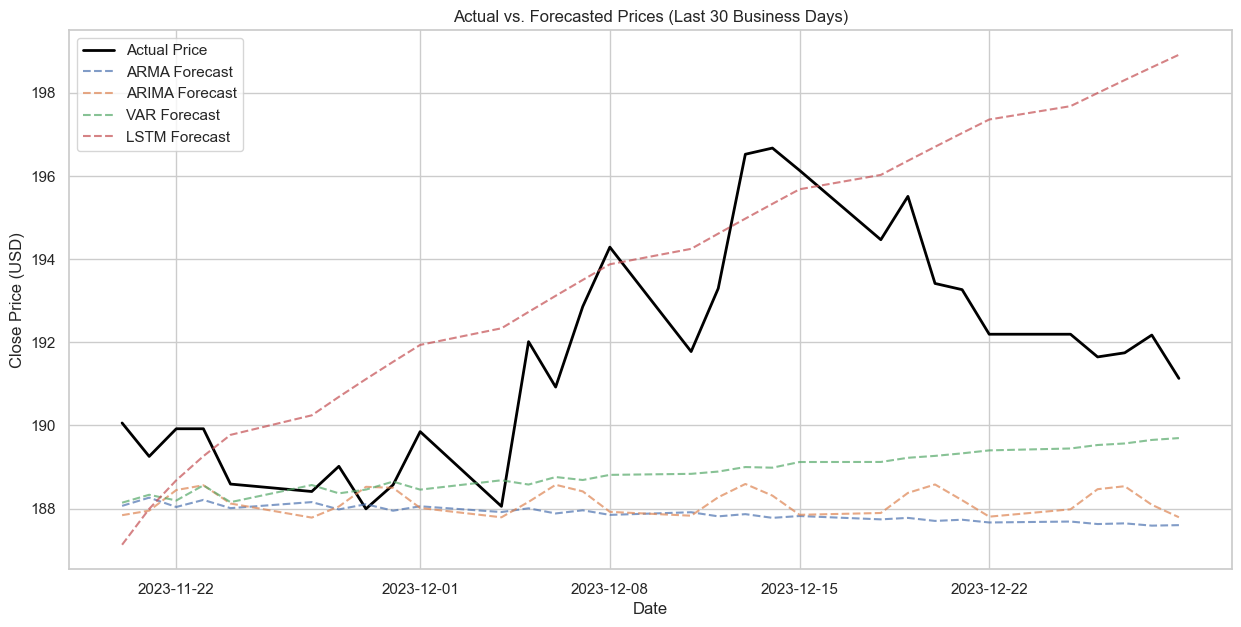

In [37]:
# --- Step 11: Evaluation — Compare All Models (MAE, RMSE, MAPE) ---
print("\n--- Step 11: Evaluation — Compare All Models (MAE, RMSE, MAPE) ---")

# Function to calculate metrics
def calculate_metrics(actual, predicted):
    actual, predicted = actual.align(predicted, join='inner', axis=0)
    if predicted.empty:
        return np.nan, np.nan, np.nan

    # Convert to Series if DataFrame
    if isinstance(actual, pd.DataFrame):
        actual = actual.iloc[:, 0]
    if isinstance(predicted, pd.DataFrame):
        predicted = predicted.iloc[:, 0]

    mae = np.mean(np.abs(actual - predicted))
    rmse = np.sqrt(np.mean((actual - predicted)**2))

    mask = actual != 0
    if mask.sum() == 0:
        mape = np.nan
    else:
        mape = np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100

    return mae, rmse, mape

results = {}
actual = test_df_close['Close']

# Safely evaluate only defined models
if 'arma_forecast_eval_series' in locals():
    results['ARMA'] = calculate_metrics(actual, arma_forecast_eval_series)
if 'arima_forecast_eval_series' in locals():
    results['ARIMA'] = calculate_metrics(actual, arima_forecast_eval_series)
if 'var_forecast_eval_series' in locals():
    results['VAR'] = calculate_metrics(actual, var_forecast_eval_series)
if 'lstm_forecast_eval_series' in locals():
    results['LSTM'] = calculate_metrics(actual, lstm_forecast_eval_series)

# Create a DataFrame for comparison
metrics_df = pd.DataFrame.from_dict(results, orient='index', columns=['MAE', 'RMSE', 'MAPE (%)'])
print("\n--- Model Performance Comparison ---")
print(metrics_df)

# Plotting Comparison
plt.figure(figsize=(15, 7))
plt.plot(actual, label='Actual Price', color='black', linewidth=2)

# Plot only available forecasts
if 'arma_forecast_eval_series' in locals():
    plt.plot(arma_forecast_eval_series, label='ARMA Forecast', linestyle='--', alpha=0.7)
if 'arima_forecast_eval_series' in locals():
    plt.plot(arima_forecast_eval_series, label='ARIMA Forecast', linestyle='--', alpha=0.7)
if 'var_forecast_eval_series' in locals():
    plt.plot(var_forecast_eval_series, label='VAR Forecast', linestyle='--', alpha=0.7)
if 'lstm_forecast_eval_series' in locals():
    plt.plot(lstm_forecast_eval_series, label='LSTM Forecast', linestyle='--', alpha=0.7)

plt.title('Actual vs. Forecasted Prices (Last 30 Business Days)')
plt.xlabel('Date')
plt.ylabel('Close Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

Interpretation of Evaluation Metrics:

MAE (Mean Absolute Error): Represents the average absolute difference between the predicted and actual values. It's in the same units as your data (USD in this case).

Observation: LSTM has the lowest MAE (2.718848), followed by VAR (2.935463), ARIMA (3.589647), and ARMA (3.855893).

Meaning: On average, the LSTM model's predictions are closest to the actual stock prices, with an average absolute error of approximately $2.72. The ARMA model, on the other hand, has the largest average absolute error at about $3.86.

RMSE (Root Mean Squared Error): This metric also measures the average magnitude of the errors, but it gives higher weight to larger errors due to the squaring. It's also in the same units as your data.

Observation: Similar to MAE, LSTM has the lowest RMSE (3.412251), followed by VAR (3.666012), ARIMA (4.347689), and ARMA (4.658068).

Meaning: The LSTM model not only has smaller average errors but also handles larger errors better than the other models. The higher RMSE for ARMA and ARIMA suggests they might have had some predictions that were significantly off.

MAPE (Mean Absolute Percentage Error): Expresses the average absolute error as a percentage of the actual values. This is a scale-independent metric, useful for comparing model accuracy across different datasets or different scales of data.

Observation: LSTM again shows the best performance with the lowest MAPE (1.420629%), followed by VAR (1.516673%), ARIMA (1.855965%), and ARMA (1.993660%).

Meaning: The LSTM model's predictions are, on average, within 1.42% of the actual stock prices. This is a very good indicator of its relative accuracy, as it means the predictions are consistently close to the true values in a percentage sense. ARMA, with nearly 2% MAPE, is the least accurate in percentage terms.

Overall Conclusion:

Based on all three evaluation metrics (MAE, RMSE, and MAPE), the LSTM model demonstrates the best performance among the models you've compared (ARMA, ARIMA, VAR, and LSTM) for forecasting Apple stock prices on your test set. It consistently shows the lowest error values, indicating higher accuracy and better predictive power for this specific dataset and forecasting horizon.

The VAR model also performs quite well, coming in second across all metrics, which highlights the potential benefit of incorporating multiple related time series (like 'Volume') if those relationships are significant. ARIMA is next, and ARMA shows the highest errors, which is expected as it doesn't account for differencing (non-stationarity) directly in the same way ARIMA does, and it doesn't capture multivariate relationships or complex non-linear patterns like VAR or LSTM.